# **Visualisations des avis clients**

**Objectif** : Créer des visualisations à partir des analyses thématiques et de sentiments.

**Ce notebook utilise** :
- Les données complètes : `data/processed/analyse_complete.parquet`

**Visualisations prévues** :
- Nuages de mots par thème (topic)
- Distribution des sentiments par catégorie
- Top n-grammes (mots fréquents)
- Comparaison français/anglais
- Distribution des topics dominants

## **Imports**

In [20]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer


plt.style.use('ggplot')
%matplotlib inline

In [3]:
# configuration
PROJET_ROOT = Path.cwd().parent.parent
DATA_PROCESSED = PROJET_ROOT / "data" / "processed"

## **Chargement des données**

In [7]:
# chargement des données complètes
df_avis = pd.read_parquet(DATA_PROCESSED / "analyse_complete.parquet")
print(f"Données chargées : {df_avis.shape}")
df_avis[['langue', 'topic_nom', 'sentiment_categorie']].head() # Aperću de quelques colonnes

Données chargées : (5946, 15)


,langue,topic_nom,sentiment_categorie
0,fr,Expérience francophone,positif
1,fr,Décoration / Vétusté,neutre
2,fr,Expérience francophone,positif
3,en,Service / Fidélité,neutre
4,fr,Expérience francophone,positif


## **Distribution Des Sentiments**

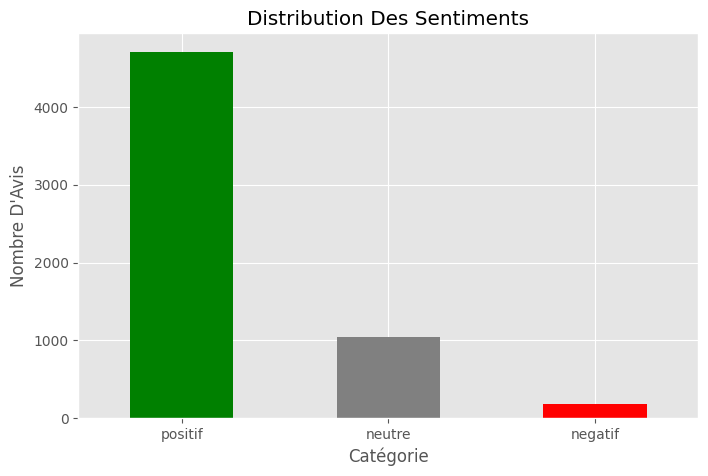

In [8]:
# Graphique à barres des sentiments
sentiment_counts = df_avis['sentiment_categorie'].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Distribution Des Sentiments')
plt.xlabel('Catégorie')
plt.ylabel("Nombre D'Avis")
plt.xticks(rotation=0)
plt.show()

## **Distribution Des Sentiments Par Langue**

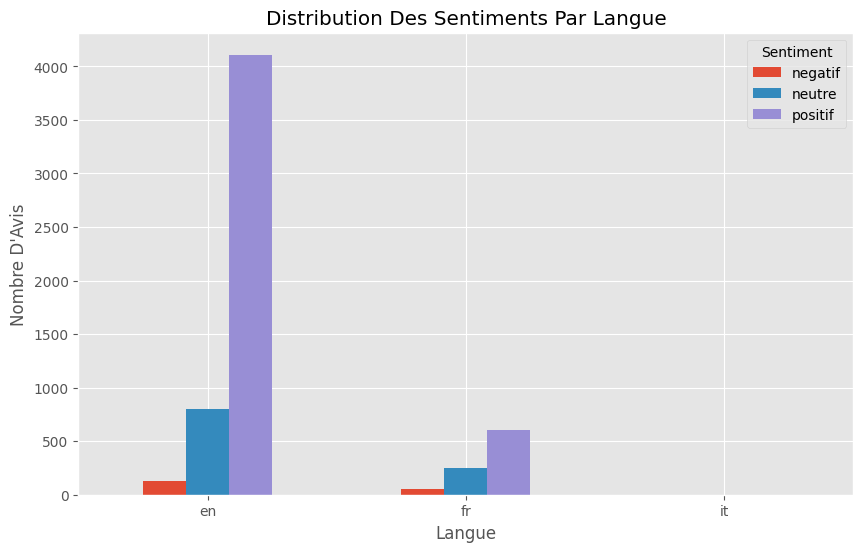

In [15]:
# Sentiments par langue
sentiment_langue = pd.crosstab(df_avis['langue'], df_avis['sentiment_categorie'])

sentiment_langue.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution Des Sentiments Par Langue')
plt.xlabel('Langue')
plt.ylabel("Nombre D'Avis")
plt.legend(title='Sentiment')
plt.xticks(rotation=0)
plt.show()

### **Observations:**
- La majorité des avis sont positifs (environ 4700), avec une proportion beaucoup plus faible d'avis neutres (environ 1000) et très peu d'avis négatifs (moins de 200). Cela indique une satisfaction générale de la clientèle.

- La comparaison par langue montre que les avis en anglais sont majoritairement positifs, tandis que les avis en français, bien que majoritairement positifs aussi, présentent une proportion légèrement plus élevée d'avis neutres et négatifs. La clientèle francophone semble légèrement plus exigeante ou critique.

## **Distribution Des Topics Dominants**

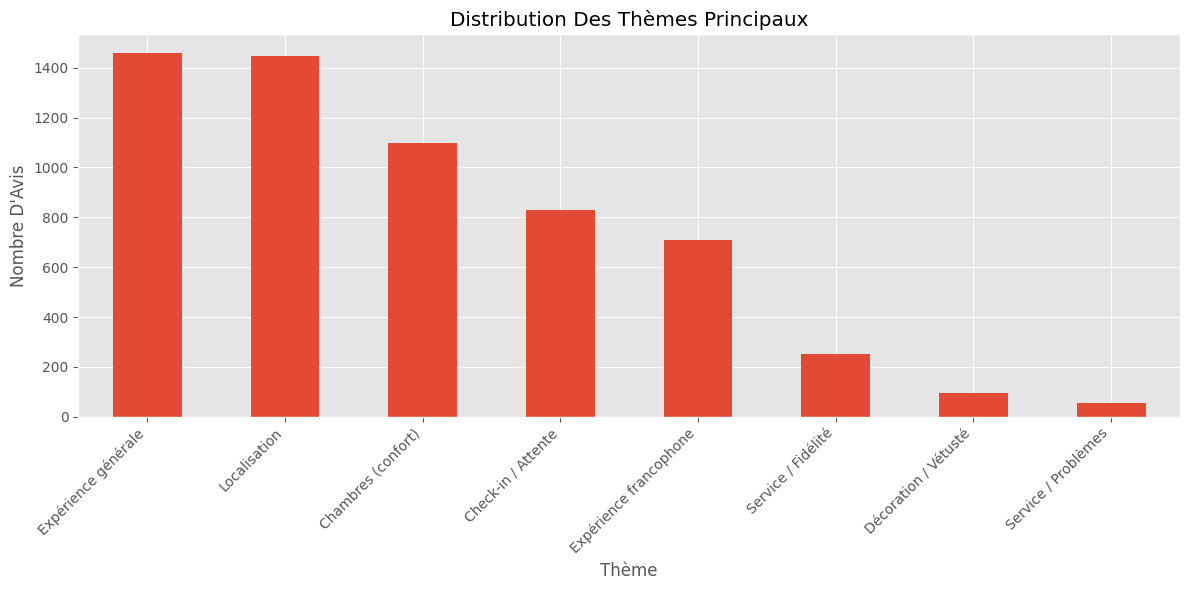

In [16]:
# Distribution des topics
topic_counts = df_avis['topic_nom'].value_counts()

plt.figure(figsize=(12, 6))
topic_counts.plot(kind='bar')
plt.title('Distribution Des Thèmes Principaux')
plt.xlabel('Thème')
plt.ylabel("Nombre D'Avis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Observations:**
- En fonction de notre étiquettage, les thèmes les plus fréquents sont "Expérience générale", "Localisation" et "Chambres (confort)", ce qui nous semble cohérent pour un hôtel. 

- "Check-in / Attente" et "Service / Problèmes" apparaissent moins fréquemment, ce qui est positif car ces thèmes sont souvent associés à des expériences négatives.

- On note une présence significative d'"Expérience francophone" comme thème distinct, confirmant que les avis en français traitent de sujets spécifiques ou avec une perspective différente.

## **Nuages De Mots Par Thème**

### **Thème "Expérience générale"**

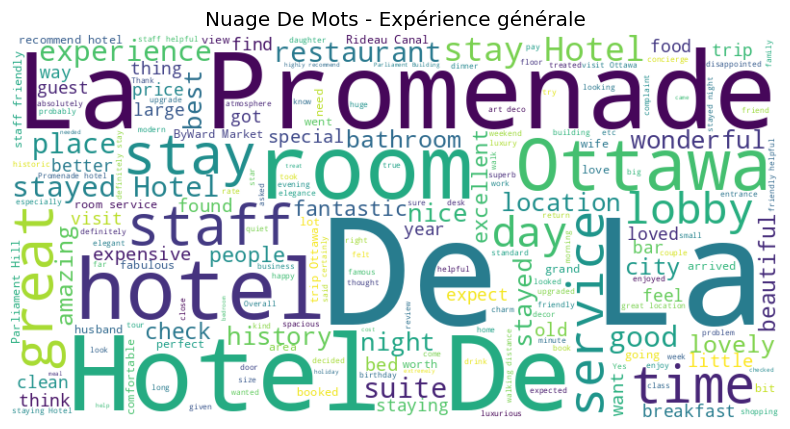

In [17]:
theme = "Expérience générale"
tokens_theme = df_avis[df_avis['topic_nom'] == theme]['tokens_clean'].explode().tolist()
texte_theme = ' '.join(tokens_theme)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texte_theme)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title(f"Nuage De Mots - {theme}")
plt.axis('off')
plt.show()

### **Thème "Localisation"**

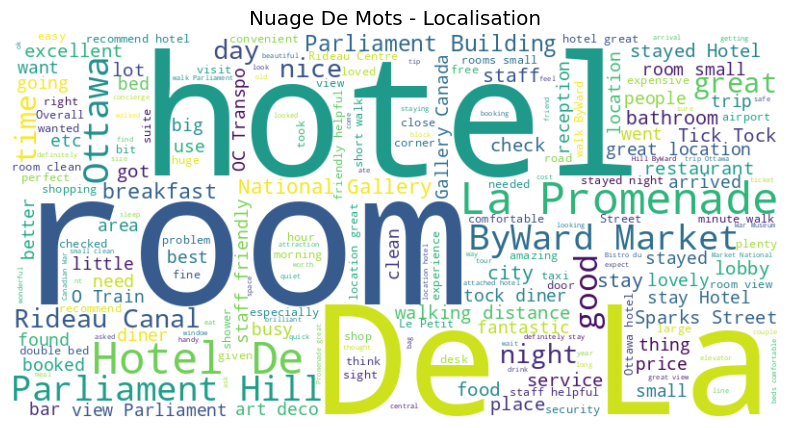

In [18]:
# Nuage de mots pour le thème "Localisation"
theme = "Localisation"
tokens_theme = df_avis[df_avis['topic_nom'] == theme]['tokens_clean'].explode().tolist()
texte_theme = ' '.join(tokens_theme)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texte_theme)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title(f"Nuage De Mots - {theme}")
plt.axis('off')
plt.show()

### **Thème "Chambres (confort)"**

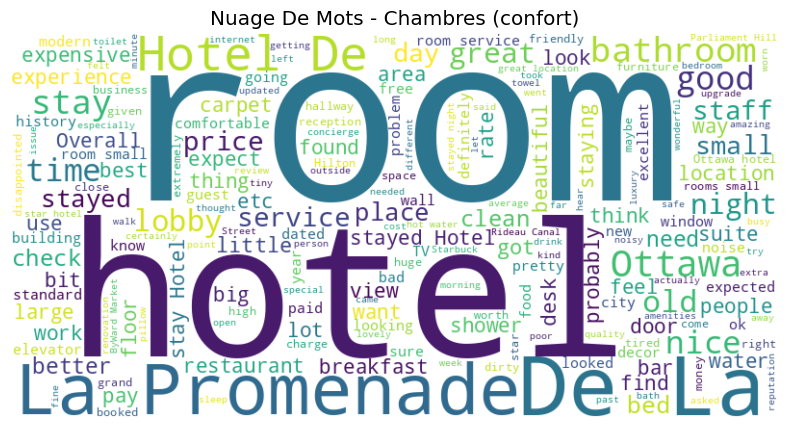

In [19]:
# Nuage de mots pour le thème "Chambres (confort)"
theme = "Chambres (confort)"
tokens_theme = df_avis[df_avis['topic_nom'] == theme]['tokens_clean'].explode().tolist()
texte_theme = ' '.join(tokens_theme)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texte_theme)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title(f"Nuage De Mots - {theme}")
plt.axis('off')
plt.show()

### **Observations:**

**Limite majeure** : La persistance de "de" et "la" dans tous les nuages de mots révèle que spaCy n'a pas correctement identifié ces mots comme stop words, étant donné qu'ils font partie intégrante du nom **"Hôtel De La Promenade"**. Aucun autre stop word ne s'est repété confirmant bel et bien qu'ils proviennent du nom de l'hôtel.

**Expérience générale** : Les mots dominants sont "stay", "hotel", "room", "service" et "recommend". La présence de "de" et "la" en grands caractères confirme le problème technique mentionné.

**Localisation** : "parliament", "ottawa", "location", "great" et "walk" ressortent fortement, ce qui est cohérent avec la proximité du Parlement et l'attrait touristique de la région. "de" et "la" sont également visibles.

**Chambres (confort)** : "room", "bed", "bathroom", "small", "comfortable", "clean" dominent. Ce thème capture les commentaires sur la taille des chambres, la literie et la propreté. La présence de "small" suggère que certains clients trouvent les chambres étroites.


## **Top N-Grammes (Mots Fréquents)**

In [21]:
# Top 10 unigrammes (mots simples)
def top_ngrammes(corpus, ngram_range=(1,1), n=10):
	vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=None)
	bag_of_words = vectorizer.fit_transform(corpus)
	sum_words = bag_of_words.sum(axis=0)
	words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
	words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
	return words_freq[:n]

In [22]:
print("Top 10 mots simples:")
unigrammes = top_ngrammes(df_avis['texte_pour_lda'], ngram_range=(1,1), n=10)
for mot, freq in unigrammes:
	print(f"{mot}: {freq}")

Top 10 mots simples:
hotel: 14217
room: 9186
promenade: 5688
la: 5356
de: 5351
ottawa: 4518
stay: 3442
staff: 3055
great: 2969
rooms: 2692


In [23]:
# Top 10 bigrammes (paires de mots)
print("\nTop 10 bigrammes:")
bigrammes = top_ngrammes(df_avis['texte_pour_lda'], ngram_range=(2,2), n=10)
for mot, freq in bigrammes:
    print(f"{mot}: {freq}")


Top 10 bigrammes:
de la: 5329
la promenade: 5322
hotel de: 5300
byward market: 954
parliament hill: 937
stayed hotel: 797
stay hotel: 704
rideau canal: 671
room service: 510
parliament buildings: 437


In [24]:
# Top 10 trigrammes (triplets de mots)
print("\nTop 10 trigrammes:")
trigrammes = top_ngrammes(df_avis['texte_pour_lda'], ngram_range=(3,3), n=10)
for mot, freq in trigrammes:
    print(f"{mot}: {freq}")


Top 10 trigrammes:
de la promenade: 5322
hotel de la: 5300
stayed hotel de: 713
stay hotel de: 533
tick tock diner: 236
national gallery canada: 194
staying hotel de: 170
view parliament buildings: 164
impression hotel soon: 155
hotel soon walked: 155


### **Observations:**

- **Unigrammes** : "hotel", "room" et "promenade" dominent logiquement. La présence de "la" et "de" dans le top 5 confirme une nouvelle fois le problème de filtrage des stop words lié au nom de l'hôtel.

- **Bigrammes** : "de la", "la promenade" et "hotel de" occupent les trois premières places, directement liés au nom "Hôtel De La Promenade". Viennent ensuite des lieux touristiques ("byward market", "parliament hill", "rideau canal") et des expressions liées au séjour ("stayed hotel", "stay hotel").

- **Trigrammes** : "de la promenade" et "hotel de la" sont massivement en tête, toujours à cause du nom de l'hôtel. On note ensuite des combinaisons comme "stayed hotel de" et "stay hotel de", ainsi que des points d'intérêt locaux ("tick tock diner", "national gallery canada").

- **Conclusion** : Le nom de l'hôtel "De La Promenade" crée un biais important dans les fréquences de mots, masquant en partie le vocabulaire thématique plus intéressant pour l'analyse. Une amélioration future consisterait à traiter ce nom comme une entité unique plutôt que comme des mots séparés.

## **Synthèse Générale Des Visualisations**

**Points clés:**

1. **Satisfaction client** : 79% d'avis positifs, seulement 3% négatifs.

2. **Thèmes principaux** : Expérience générale, localisation et confort des chambres dominent les conversations.

3. **Différence linguistique** : Les avis en français sont légèrement plus critiques que les anglais.

4. **Problème technique** : Le nom "De La Promenade" parasite l'analyse lexicale.

5. **Attraits touristiques** : Parlement, canal Rideau, Byward Market reviennent fréquemment, confirmant l'importance de la localisation.

**Recommandations pour l'hôtel** :
- Investir dans le confort des chambres (taille et literie mentionnées)
- Capitaliser sur la localisation privilégiée
- Surveiller la différence de perception clientèle francophone vs anglophone